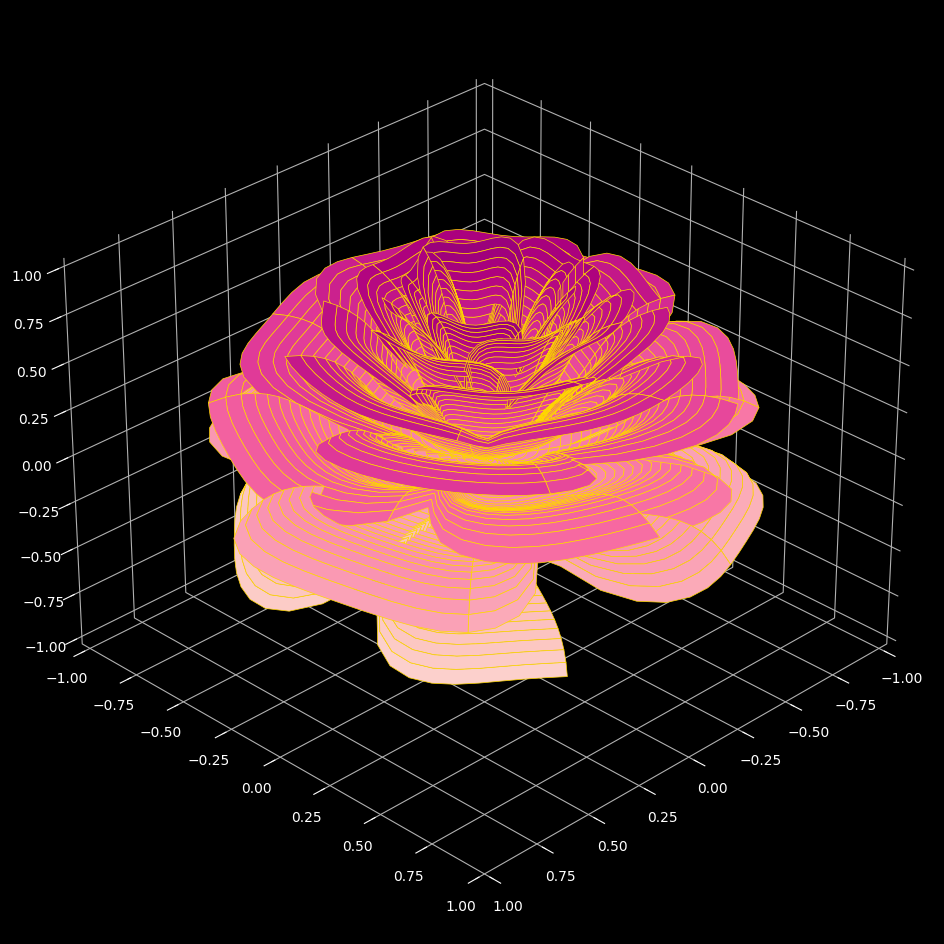

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib.colors as mcolors

# Global parameters
THETA_START = -2 * np.pi
THETA_END = 15 * np.pi
THETA_POINTS = 576
X_POINTS = 25
GRID_FRAMES = 20  # Number of frames to draw the grid
EXTRA_ROTATION_FRAMES = 120  # Number of frames for extra rotation after rose is fully drawn
ROTATION_SPEED = 1  # Degrees of rotation per frame
FPS = 30  # Frames per second for the output video
DPI = 150  # Dots per inch for the output video
BITRATE = 1800  # Bitrate for the output video

# Rose color parameters
ROSE_COLOR_START = 0.2
ROSE_COLOR_END = 0.8
ROSE_EDGE_COLOR = 'gold'
ROSE_EDGE_WIDTH = 0.5

# Plot style parameters
BACKGROUND_COLOR = 'black'
GRID_COLOR = 'white'
GRID_ALPHA = 0.3
AXIS_COLOR = 'white'

def rose(x, theta):
    phi = (np.pi / 2) * np.exp(-theta / (8 * np.pi))
    X = 1 - (1 / 2) * ((5 / 4) * (1 - np.mod(3.6 * theta, 2 * np.pi) / np.pi) ** 2 - 1 / 4) ** 2
    y = 1.95653 * x ** 2 * (1.27689 * x - 1) ** 2 * np.sin(phi)
    r = X * (x * np.sin(phi) + y * np.cos(phi))
    return r * np.sin(theta), r * np.cos(theta), X * (x * np.cos(phi) - y * np.sin(phi))

# Generate data
theta = np.linspace(THETA_START, THETA_END, THETA_POINTS)
x = np.linspace(0, 1, X_POINTS)
theta, x = np.meshgrid(theta, x)
X, Y, Z = rose(x, theta)

# Calculate the final dimensions of the entire rose
max_dim = max(np.max(np.abs(X)), np.max(np.abs(Y)), np.max(np.abs(Z)))

# Plotting
fig = plt.figure(facecolor=BACKGROUND_COLOR, figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor(BACKGROUND_COLOR)

# Set up the axes
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.set_pane_color((0, 0, 0, 0))
    axis.pane.fill = False
    axis.label.set_color(AXIS_COLOR)
    axis.set_tick_params(colors=AXIS_COLOR)

# Set axis limits
ax.set_xlim(-max_dim, max_dim)
ax.set_ylim(-max_dim, max_dim)
ax.set_zlim(-max_dim, max_dim)

# Initialize plot
plot = [ax.plot_surface(X[:, :1], Y[:, :1], Z[:, :1], color='red', edgecolor='none')]

# Create a custom colormap for the rose
rose_colors = plt.cm.RdPu(np.linspace(ROSE_COLOR_START, ROSE_COLOR_END, 100))
rose_cmap = mcolors.LinearSegmentedColormap.from_list("custom_rose", rose_colors)

def update(frame):
    ax.clear()
    ax.set_facecolor(BACKGROUND_COLOR)

    # Reset labels, ticks, and limits
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.set_pane_color((0, 0, 0, 0))
        axis.pane.fill = False
        axis.label.set_color(AXIS_COLOR)
        axis.set_tick_params(colors=AXIS_COLOR)
    ax.set_xlim(-max_dim, max_dim)
    ax.set_ylim(-max_dim, max_dim)
    ax.set_zlim(-max_dim, max_dim)

    # Set view angle (static)
    ax.view_init(elev=30, azim=45)

    if frame < GRID_FRAMES:
        # Draw grid lines one by one
        ax.grid(True, linestyle='--', color=GRID_COLOR, alpha=GRID_ALPHA)
    else:
        # Draw full grid and rose pixel by pixel
        ax.grid(True, linestyle='--', color=GRID_COLOR, alpha=GRID_ALPHA)

        # Calculate the number of columns to draw
        columns_to_draw = min(frame - GRID_FRAMES + 1, X.shape[1])

        # Rotate only the rose data
        angle = (frame - GRID_FRAMES) * ROTATION_SPEED
        rot_matrix = np.array([
            [np.cos(np.radians(angle)), -np.sin(np.radians(angle)), 0],
            [np.sin(np.radians(angle)), np.cos(np.radians(angle)), 0],
            [0, 0, 1]
        ])

        rotated_data = np.dot(np.column_stack((X[:, :columns_to_draw].flatten(),
                                               Y[:, :columns_to_draw].flatten(),
                                               Z[:, :columns_to_draw].flatten())), rot_matrix.T)

        X_rot = rotated_data[:, 0].reshape(X[:, :columns_to_draw].shape)
        Y_rot = rotated_data[:, 1].reshape(Y[:, :columns_to_draw].shape)
        Z_rot = rotated_data[:, 2].reshape(Z[:, :columns_to_draw].shape)

        # Plot the rose surface
        plot[0] = ax.plot_surface(X_rot, Y_rot, Z_rot,
                                  cmap=rose_cmap,
                                  edgecolor=ROSE_EDGE_COLOR,
                                  linewidth=ROSE_EDGE_WIDTH,
                                  antialiased=True)

    return plot

# Animation
total_frames = GRID_FRAMES + X.shape[1] + EXTRA_ROTATION_FRAMES
anim = FuncAnimation(fig, update, frames=total_frames, interval=1000/FPS, blit=False)

# Save animation as MP4
writer = FFMpegWriter(fps=FPS, metadata=dict(artist='Me'), bitrate=BITRATE)
anim.save('rose_animation.mp4', writer=writer, dpi=DPI)

plt.show()

In [ ]:
plt.savefig('rose_last_frame.png', dpi=DPI, facecolor=BACKGROUND_COLOR)


<Figure size 640x480 with 0 Axes>